## <span style='text-decoration: double underline;color:rgb(10,110,217)'>**Results Regressor Model**</span>

```py   
@ex.config
def config():
    # Global configuration:
    seeds = [221, 502, 700, 1204, 3340, 4501, 6054, 6621,8421, 15678, 19302, 38475, 77293, 91827, 99100]  #  
    deltas = [1] # ,2,3,4
    shapes = [(15,15)] # , (20,20), (25,25), (30,30)

    path2save:str = './Data'
    n_hidden_filters:list[int] = [1,15,32,64]
    kernel_size:int = 3
    mlp_hidden:tuple[int] = (64,32)
    use_stats:bool = False  
    padding_mode:str = 'circular'
    optimizer:str = 'Adam'
    learning_rate:float = 0.0001
    epochs:int = 10
    batch_size:int = 2**8
    metrics2compute:list= ['MeanAbsoluteError', 'MeanSquaredError', 'R2Score']
```

In [40]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
from pathlib import Path
import utils.evaluation_tools as eval_tools

delta = 1 
shape = (15,15)
parent_folder = './Data'
seed2plot = 221
seeds = [221, 502, 700, 1204, 3340, 4501, 6054, 6621,8421, 15678, 19302, 38475, 77293, 91827, 99100]  

cols2omit = 0
num_rows = 1

figsize = (12,9)
subplots_grid = (3,3)
suptitle = 'DiffGoL Model'
th_ranges = [(0.45, 0.55), (0.40, 0.60), (0.35, 0.65)]

metrics2compute = ['Accuracy', 'Recall', 'Specificity','Precision', 'F1Score']

model_hp = {'n_hidden_filters':[1,15,32,64], 'kernel_size':3, 'mlp_hidden':(64,32), 'use_stats':False, 'padding_mode':'circular'}

train_history_paths = eval_tools.get_paths_results('train_history.csv', parent_folder, seeds, shape, delta)
predictions_paths = eval_tools.get_paths_results('predictions.csv', parent_folder, seeds, shape, delta)
test_results_paths = eval_tools.get_paths_results('test_results.csv', parent_folder, seeds, shape, delta)
test_data = eval_tools.get_paths_results('testGoL.csv', parent_folder, seeds, shape, delta)
confusion_matrix = eval_tools.get_paths_results('confusion_matrix.csv', parent_folder, seeds, shape, delta)
paths2model = eval_tools.get_paths_results('model.pt',parent_folder, seeds, shape, delta)
tabs2plot = Path(parent_folder)/'tabs2plot_221.csv'

### <span style='color:rgb(10,110,217)'><u>**Train Results**</u></span>

--- Metrics computed during execution ---
loss: 0.0041 ± 0.0000
val_loss: 0.0042 ± 0.0001


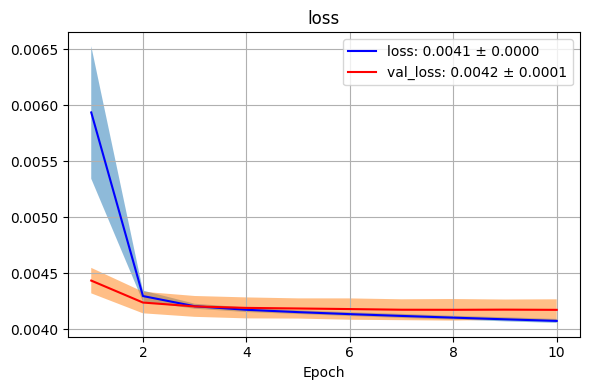

In [3]:
eval_tools.display_results(train_history_paths, 'val_', cols2omit, num_rows, True, True)

### <span style='color:rgb(10,110,217)'><u>**Test Results using Global thresholding of 0.5**</u></span>

In [4]:
# Global threshold of 0.5
eval_tools.computeCM_direct(confusion_matrix, shape, metrics2compute)

--- Results Initial states (15 seeds) ---
Accuracy: 0.8287 ± 0.0006
Recall: 0.5603 ± 0.0010
Specificity: 0.9063 ± 0.0004
Precision: 0.6335 ± 0.0008
F1Score: 0.5947 ± 0.0009


### <span style='color:rgb(10,110,217)'><u>**Test Results using Regressor model**</u></span>

In [5]:
eval_tools.display_test_results(test_results_paths,cols2omit)

--- Metrics computed during execution ---
MeanAbsoluteError: 0.1074 ± 0.0008
MeanSquaredError: 0.0300 ± 0.0007
R2Score: 0.1426 ± 0.0108


In [6]:
eval_tools.computeCM(confusion_matrix, predictions_paths, metrics2compute, shape)

--- Results Initial states (15 seeds) ---
Accuracy: 0.7807 ± 0.0015
Recall: 0.7464 ± 0.0036
Specificity: 0.7967 ± 0.0032
Precision: 0.5213 ± 0.0020
F1Score: 0.6038 ± 0.0010


### <span style='color:rgb(10,110,217)'><u>**Test Results using Otsu method**</u></span>

In [7]:
thresholds_otsu = eval_tools.computeOtsu(confusion_matrix, shape)
eval_tools.computeCM_Otsu(confusion_matrix, thresholds_otsu, shape, metrics2compute)

--- Results Initial states (15 seeds) ---
Accuracy: 0.8262 ± 0.0006
Recall: 0.6082 ± 0.0010
Specificity: 0.8914 ± 0.0004
Precision: 0.6202 ± 0.0008
F1Score: 0.6095 ± 0.0008


### <span style='color:rgb(10,110,217)'><u>**Test Results using Gaussian thresholding**</u></span>

In [38]:
eval_tools.computeCM_Gauss(confusion_matrix, shape, metrics2compute, block_size=3, C=0.01)

--- Results Initial states (15 seeds) ---
Accuracy: 0.6099 ± 0.0011
Recall: 0.6235 ± 0.0010
Specificity: 0.6060 ± 0.0014
Precision: 0.3138 ± 0.0015
F1Score: 0.4175 ± 0.0014


### <span style='color:rgb(10,110,217)'><u>**Visual plot using regressor model thresholding**</u></span>

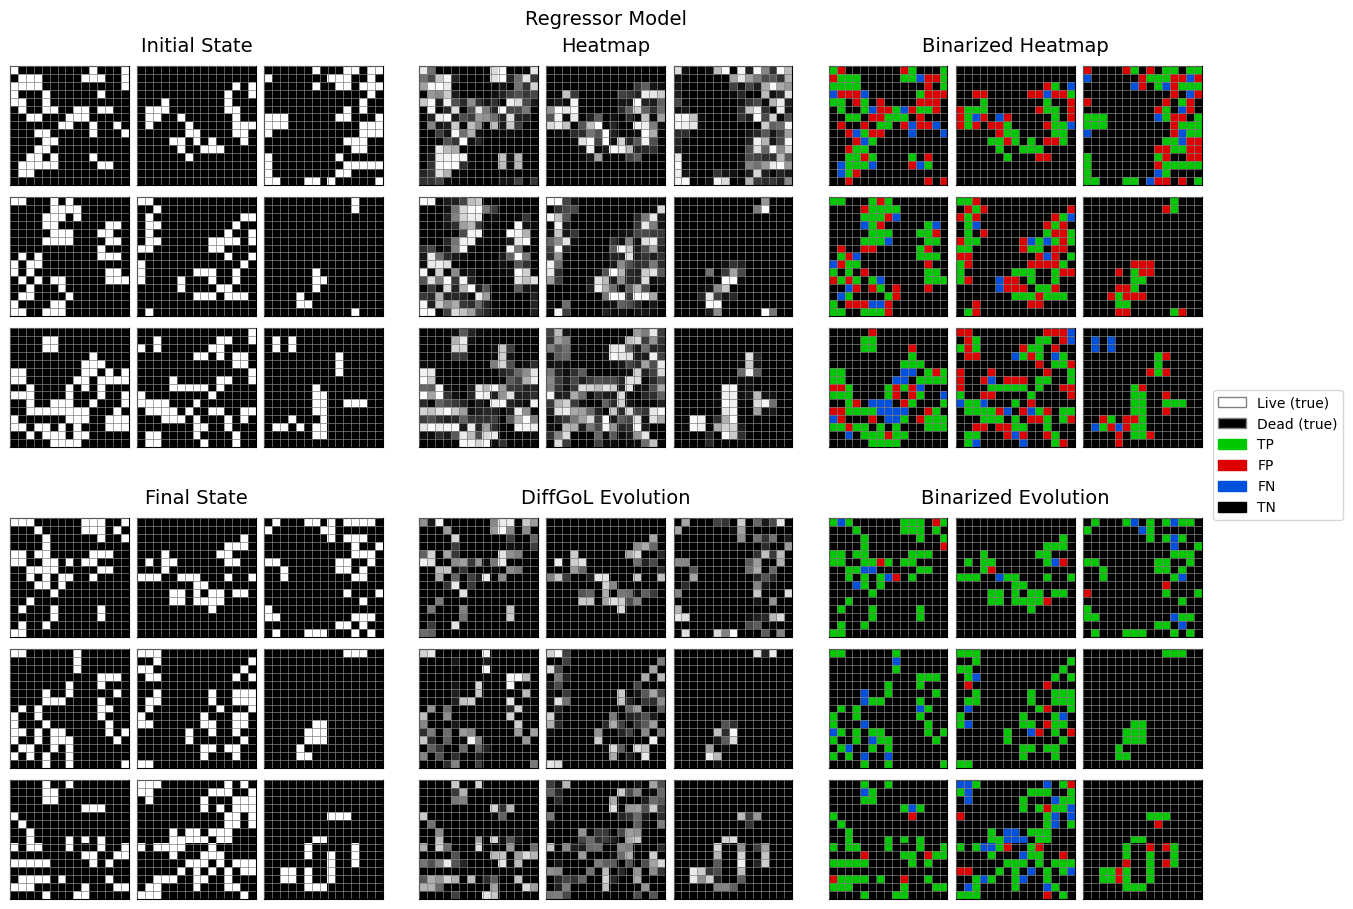

In [30]:
eval_tools.display_states(tabs2plot, paths2model, shape, model_hp)

### <span style='color:rgb(10,110,217)'><u>**Visual plot using Otsu method**</u></span>

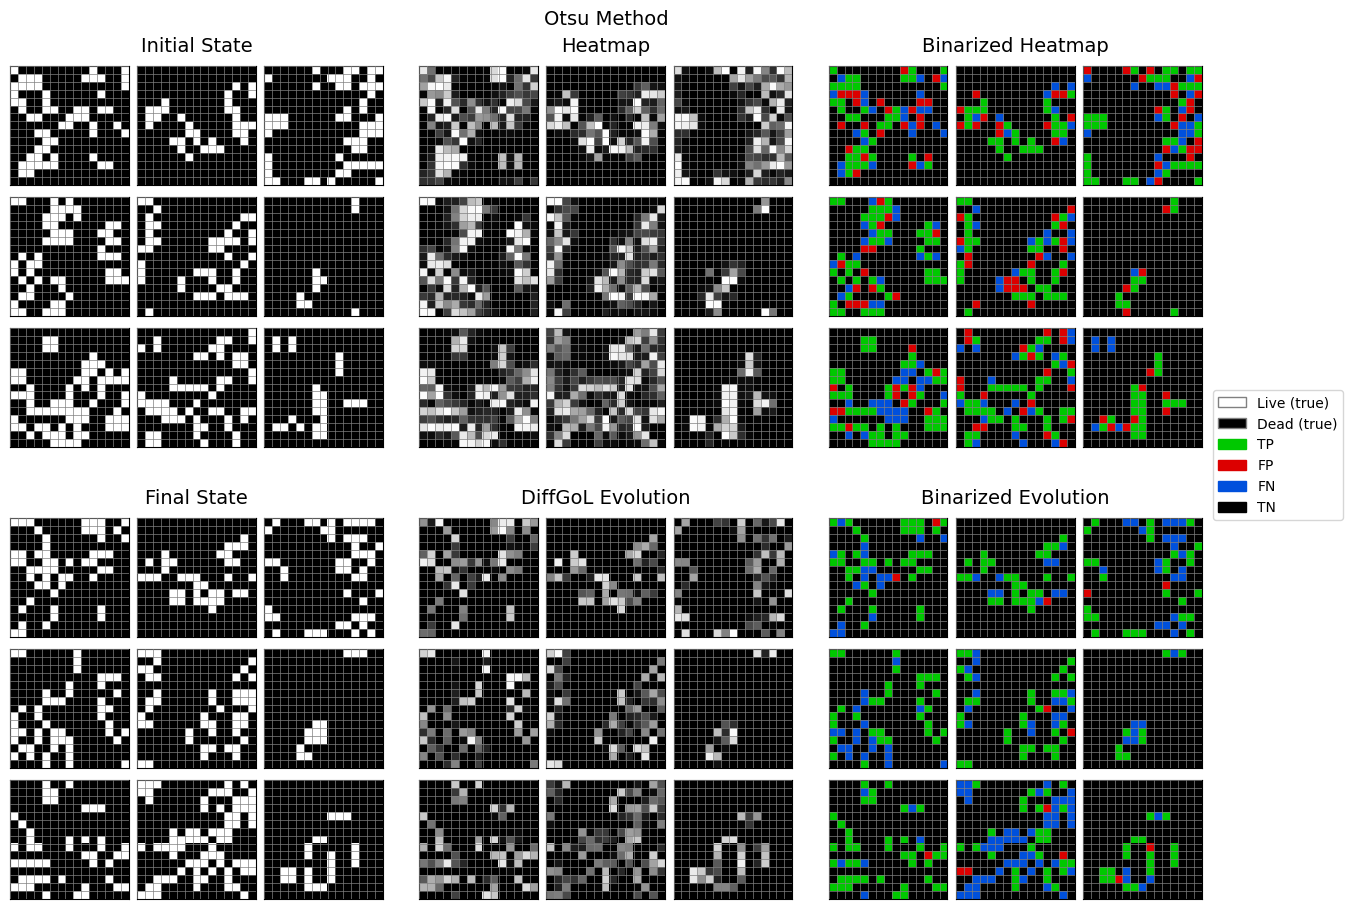

In [31]:
eval_tools.display_states(tabs2plot, paths2model, shape, model_hp, thresholds_otsu[seed2plot], 'Otsu Method')

### <span style='color:rgb(10,110,217)'><u>**Visual plot using Gaussian method**</u></span>

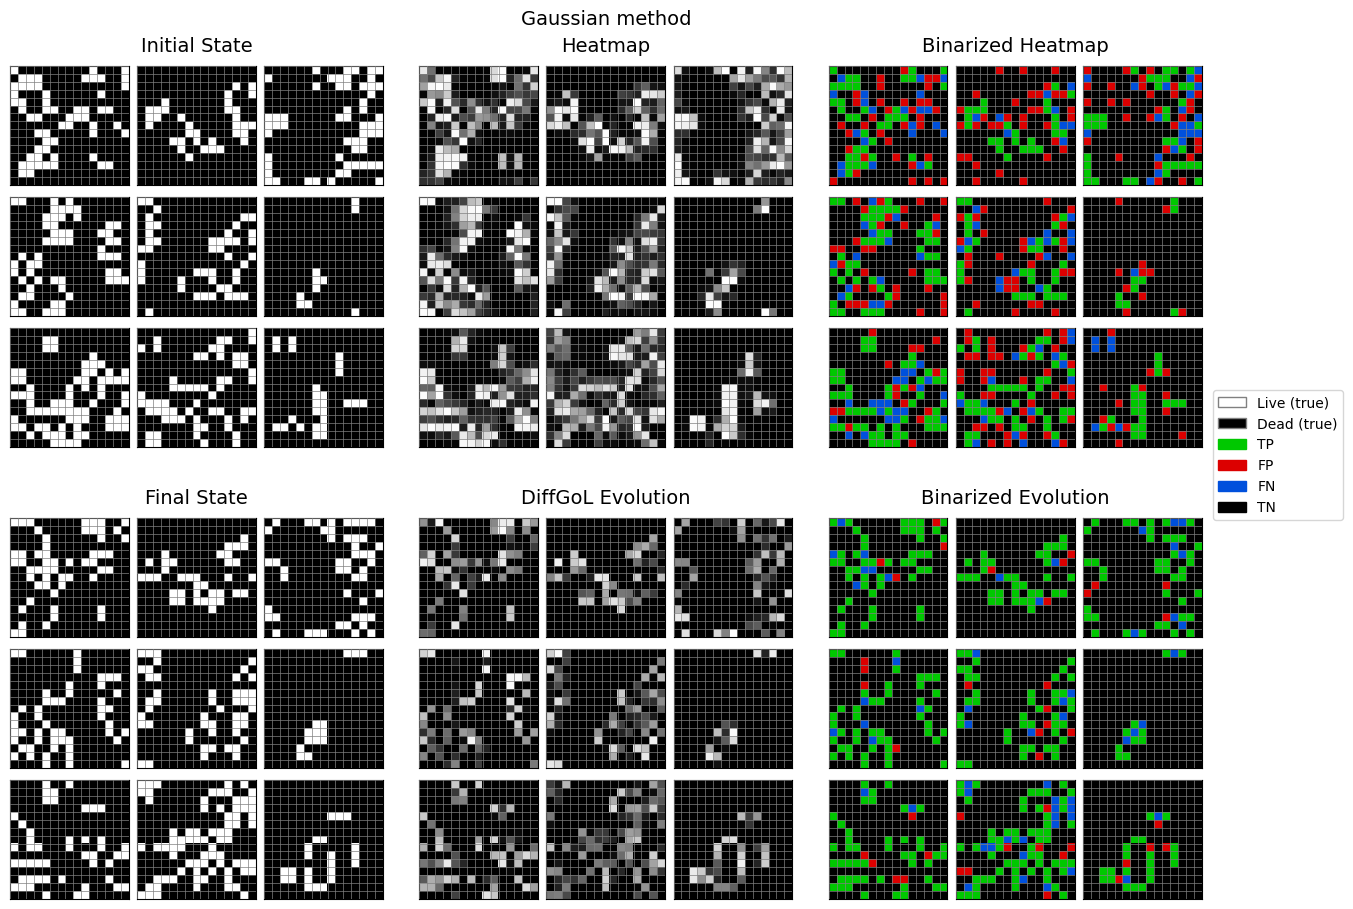

In [ ]:
eval_tools.display_states_gauss(tabs2plot, shape, block_size=3, C=0)